<a href="https://colab.research.google.com/github/ninnafil/anomaly_detection/blob/main/%D0%B2%D1%8B%D1%8F%D0%B2%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D1%88%D0%B5%D0%BD%D0%BD%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%82%D1%80%D0%B0%D0%BD%D0%B7%D0%B0%D0%BA%D1%86%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [305]:
# Загрузка и первичный анализ данных
df = pd.read_csv('bank_transactions_data_2.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [306]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [307]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [308]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
# Удаляем TransactionID
df = df.drop(['TransactionID'], axis=1)

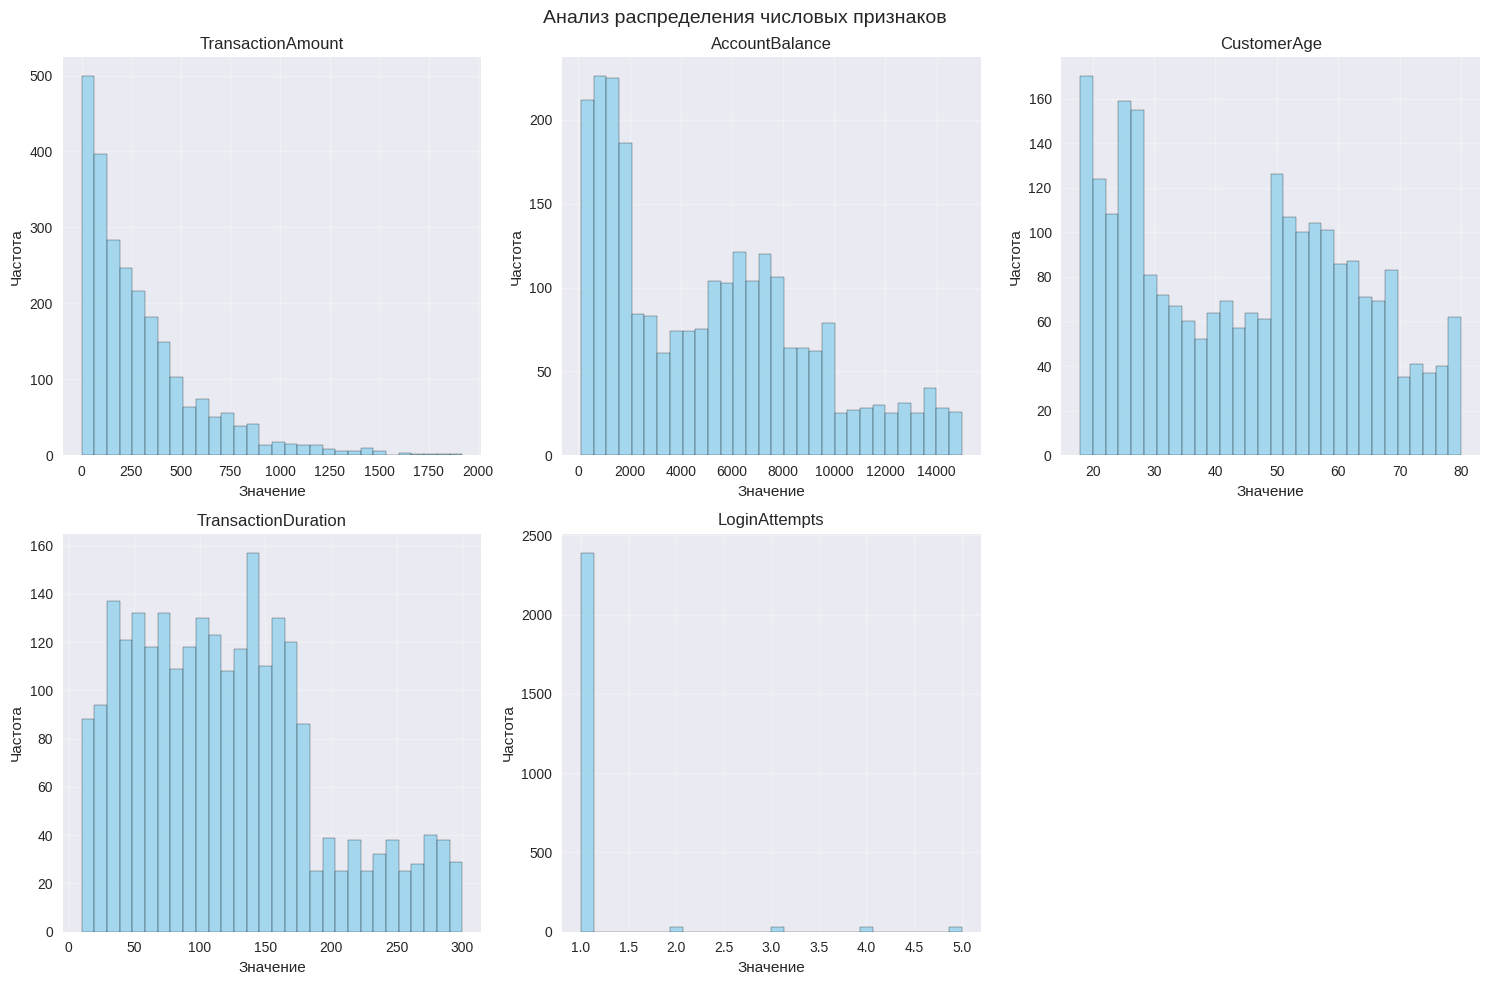

In [311]:
# Графики распределения числовых признаков
plt.figure(figsize=(15, 10))

numerical_cols = ['TransactionAmount', 'AccountBalance', 'CustomerAge',
                  'TransactionDuration', 'LoginAttempts']

for i, col in enumerate(numerical_cols[:5]):
    plt.subplot(2, 3, i+1)
    plt.hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'{col}', fontsize=12)
    plt.xlabel('Значение')
    plt.ylabel('Частота')
    plt.grid(alpha=0.3)

plt.suptitle('Анализ распределения числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [312]:
# Обработка дат и временных признаков

# Преобразование строковых дат в datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Сортировка по аккаунту и дате
df = df.sort_values(['AccountID', 'TransactionDate'])

# Создаем новый столбец для исправленных дат, заполняем датами предыдущих транзакций аккаунта
df['CorrectedPreviousDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)

# Вычисляем интервалы между транзакциями как timedelta (учитывает дни и время)
df['TransactionInterval'] = df['TransactionDate'] - df['CorrectedPreviousDate']

# Вычисляем медианный интервал (игнорируем NaT - первые транзакции)
median_timedelta = df[df['TransactionInterval'].notna()]['TransactionInterval'].median()

# Если все интервалы NaT (например, у всех аккаунтов только по одной транзакции),
# используем дефолтное значение (месяц)
if pd.isna(median_timedelta):
    median_timedelta = pd.Timedelta(days=30)

# Для первых транзакций каждого аккаунта используем медианный интервал
first_transactions = df.groupby('AccountID').head(1).index
for idx in first_transactions:
    df.at[idx, 'CorrectedPreviousDate'] = df.at[idx, 'TransactionDate'] - median_timedelta

# Заменяем исходный столбец
df['PreviousTransactionDate'] = df['CorrectedPreviousDate']
df = df.drop(columns=['CorrectedPreviousDate', 'TransactionInterval'])

# Проверка результата
print(f"Использованный медианный интервал: {median_timedelta}")
print(df[['AccountID', 'TransactionDate', 'PreviousTransactionDate']].head(10))

Использованный медианный интервал: 39 days 00:12:57
     AccountID     TransactionDate PreviousTransactionDate
1312   AC00001 2023-09-15 17:00:20     2023-08-07 16:47:23
2016   AC00001 2023-11-14 16:56:34     2023-09-15 17:00:20
2120   AC00002 2023-01-10 16:00:32     2022-12-02 15:47:35
20     AC00002 2023-02-28 16:36:58     2023-01-10 16:00:32
1476   AC00002 2023-05-05 16:35:44     2023-02-28 16:36:58
61     AC00002 2023-05-16 16:07:30     2023-05-05 16:35:44
1598   AC00002 2023-07-24 16:14:05     2023-05-16 16:07:30
1673   AC00002 2023-09-11 17:52:59     2023-07-24 16:14:05
1028   AC00002 2023-12-21 17:00:50     2023-09-11 17:52:59
2325   AC00003 2023-01-02 16:45:05     2022-11-24 16:32:08


In [313]:
# Кодирование текстовых признаков

# Кодирование TransactionType
df['IsCredit'] = (df['TransactionType'] == 'Credit').astype(int)

# Frequency Encoding для Location
location_freq = df['Location'].value_counts(normalize=True)
df['Location_Freq'] = df['Location'].map(location_freq)

# Frequency Encoding для IP Address
IP_Address_freq = df['IP Address'].value_counts(normalize=True)
df['IP_Address_Freq'] = df['IP Address'].map(IP_Address_freq)

# Frequency Encoding для DeviceID
deviceID_freq = df['DeviceID'].value_counts(normalize=True)
df['DeviceID_Freq'] = df['DeviceID'].map(deviceID_freq)

# Frequency Encoding для MerchantID
merchant_freq = df['MerchantID'].value_counts(normalize=True)
df['MerchantID_Freq'] = df['MerchantID'].map(merchant_freq)

# Frequency Encoding для Channel
channel_freq = df['Channel'].value_counts(normalize=True)
df['Channel_Freq'] = df['Channel'].map(channel_freq)

# One-Hot Encoding для CustomerOccupation
df = pd.get_dummies(df, columns=['CustomerOccupation'], prefix='Occupation', dtype="int8")

# Удаляем исходные текстовые признаки
df.drop(['TransactionType', 'Location', 'MerchantID', 'Channel', 'AccountID', 'IP Address', 'DeviceID'], axis=1, inplace=True)

In [314]:
# Создание новых временных признаков

# Разница во времени между текущей и последней транзакциями в часах
df['TimeSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / 3600

# Час транзакции
df['TransactionHour'] = df['TransactionDate'].dt.hour

# День транзакции
df['DayOfWeek'] = df['TransactionDate'].dt.weekday

df.drop(['TransactionDate', 'PreviousTransactionDate'], axis=1, inplace=True)

In [315]:
# Создание новых признаков

# Процент который составляет сумма транзакции от общей суммы счета
df['SpendingPercentage'] = df['TransactionAmount'] / (df['TransactionAmount'] + df['AccountBalance']) * 100

# Обработка LoginAttempts
df['SuspiciousLoginAttempts'] = (df['LoginAttempts'] > 2).astype(int)
df = df.drop(['LoginAttempts'], axis=1) # Удаляем исходный столбец

# Сохраняем TransactionAmount и AccountBalance для анализа
amount_stats = df[['TransactionAmount', 'AccountBalance']].describe()
df.drop(['TransactionAmount', 'AccountBalance'], axis=1, inplace=True)

In [316]:
# Нормализация числовых признаков

# Выделяем числовые и категориальные признаки
numerical_features = ['CustomerAge', 'TransactionDuration', 'TimeSinceLastTransaction', 'TransactionHour', 'DayOfWeek',
                     'SpendingPercentage', 'Location_Freq', 'MerchantID_Freq', 'Channel_Freq', 'IP_Address_Freq', 'DeviceID_Freq']
binary_features = ['IsCredit', 'SuspiciousLoginAttempts']
occupation_features = [col for col in df.columns if col.startswith('Occupation_')]

# Создаем копию DataFrame для сохранения исходных данных
df_processed = df.copy()

# Инициализация StandardScaler
scaler = StandardScaler()

# Нормализуем числовые признаки
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

# Проверка результата
print(df_processed.head())

      CustomerAge  TransactionDuration  IsCredit  Location_Freq  \
1312    -1.105984            -1.181466         0       0.441668   
2016     0.805347             0.834265         0       0.284963   
2120    -1.218415             0.962929         0      -0.028446   
20       1.479934            -1.167170         0       1.538601   
1476    -0.656259            -0.838362         0      -2.065608   

      IP_Address_Freq  DeviceID_Freq  MerchantID_Freq  Channel_Freq  \
1312        -1.059021       1.871138        -0.998241      1.274220   
2016        -0.077737      -1.944924        -0.025556     -1.146091   
2120         0.903547      -0.309469        -1.776389     -1.146091   
20          -0.077737      -1.944924        -0.025556      1.274220   
1476        -0.077737      -1.399772         1.141666      1.274220   

      Occupation_Doctor  Occupation_Engineer  Occupation_Retired  \
1312                  0                    0                   0   
2016                  0           

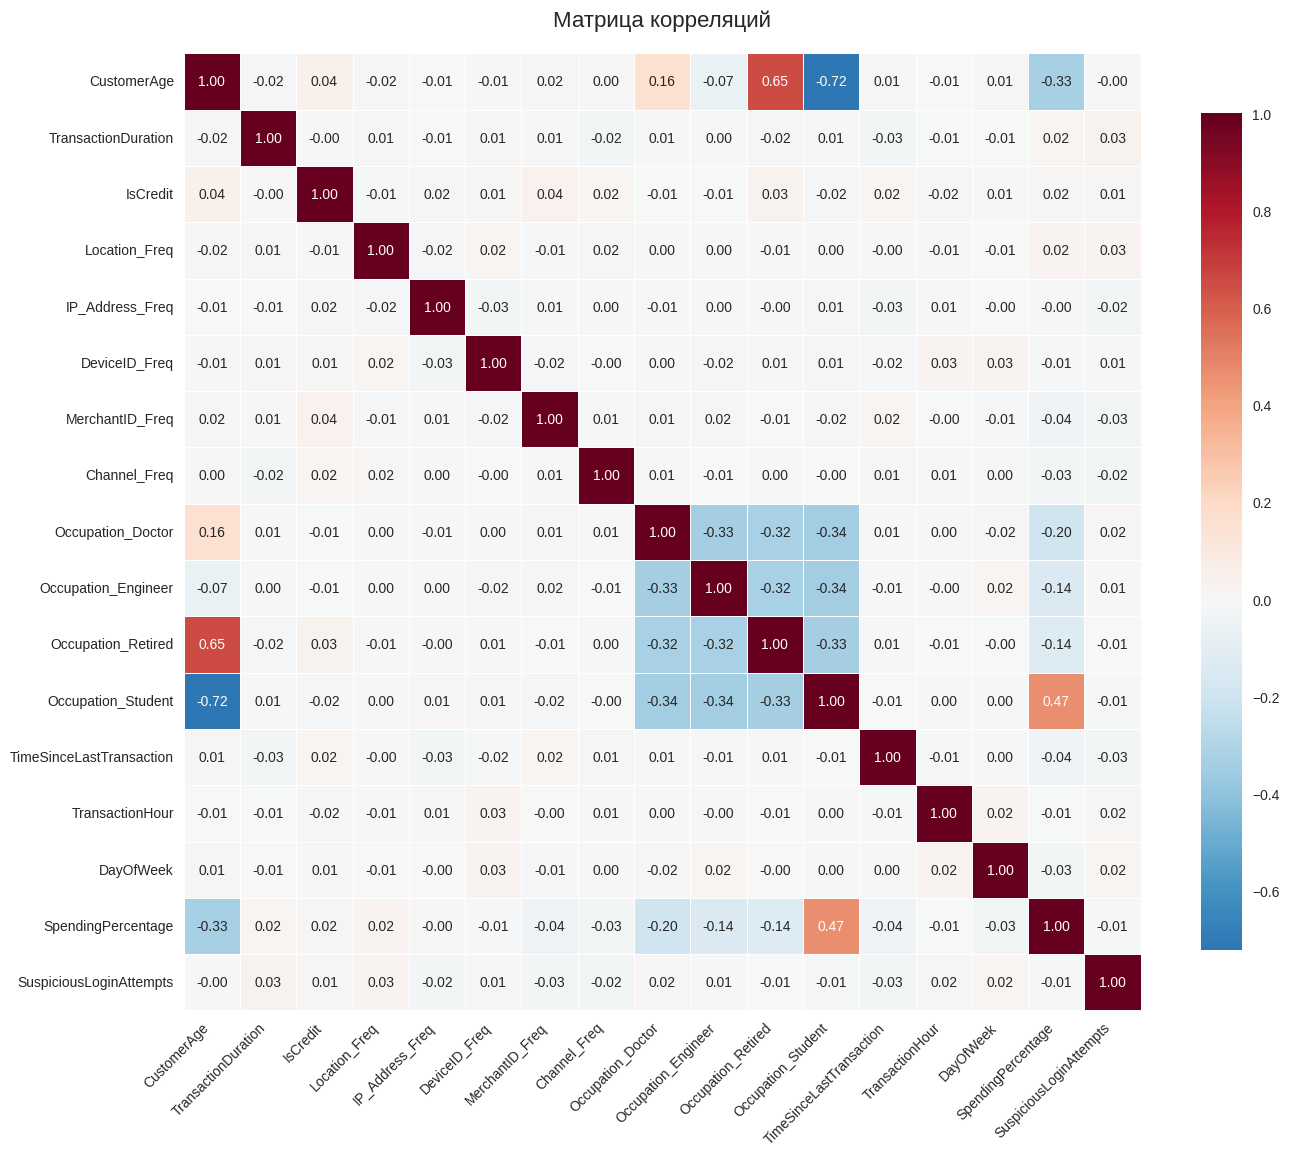

In [317]:
# Матрица корреляций для признаков после обработки

plt.figure(figsize=(14, 12))

corr_matrix = df_processed.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [318]:
# Разделяем данные на обучающую и тестовую выборки (80/20)
# Убираем SuspiciousLoginAttempts из признаков, так как это метка
features = [col for col in df_processed.columns if col != 'SuspiciousLoginAttempts']
X = df_processed[features]

# Используем SuspiciousLoginAttempts как базовую метку для стратификации
if 'SuspiciousLoginAttempts' in df_processed.columns:
    y = df_processed['SuspiciousLoginAttempts']
    X_train, X_test, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (2009, 16), Test size: (503, 16)


In [319]:
# 1. Isolation Forest
iso_model = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_model.fit(X_train)

# 2. Local Outlier Factor
lof_model = LocalOutlierFactor(novelty=True, contamination=0.1, n_neighbors=50)
lof_model.fit(X_train)

# 3. One-Class SVM
svm_model = OneClassSVM(nu=0.1, kernel='rbf', gamma='auto')
svm_model.fit(X_train)

# 4. Autoencoder
input_dim = X_train.shape[1]

# Создание автоэнкодера
autoencoder = Sequential([
    Dense(64, input_dim=input_dim),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='linear')
])
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# 5. GAN
latent_dim = 10

# Генератор
generator = Sequential([
    Dense(15, input_dim=latent_dim),
    LeakyReLU(alpha=0.2),
    Dense(30),
    LeakyReLU(alpha=0.2),
    Dense(input_dim, activation='tanh')
])

# Дискриминатор
discriminator = Sequential([
    Dense(128, input_dim=input_dim),
    LeakyReLU(0.2),
    Dropout(0.3),
    Dense(64),
    LeakyReLU(0.2),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002), metrics=['accuracy'])

# Комбинированная модель GAN
discriminator.trainable = False
gan_input = Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002))

# Обучение GAN
epochs = 100
batch_size = 32

for epoch in range(epochs):
    # Генерация фейковых данных
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    generated_data = generator.predict(noise, verbose=0)

    # Выбор реальных данных
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_data = X_train.iloc[idx].values

    # Обучение дискриминатора
    d_loss_real = discriminator.train_on_batch(real_data, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(generated_data, np.zeros((batch_size, 1)))

    # Обучение генератора через GAN
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

In [320]:
# Функция для оценки моделей
def generate_anomalies(X, n_anomalies):
    """Генерация синтетических аномалий"""
    if isinstance(X, pd.DataFrame):
        X_data = X
    else:
        X_data = pd.DataFrame(X)

    n_extreme = n_anomalies // 2
    n_combinations = n_anomalies - n_extreme

    # Экстремальные аномалии
    extreme = np.random.randn(n_extreme, X_data.shape[1])
    extreme = extreme * X_data.std().values * 10 + X_data.mean().values

    # Комбинационные аномалии
    combinations = []
    for _ in range(n_combinations):
        sample = X_data.iloc[np.random.randint(0, len(X_data))].copy()
        cols = np.random.choice(X_data.columns, size=np.random.randint(2, 5), replace=False)
        for col in cols:
            if col in binary_features:
                sample[col] = 1 - sample[col]
            else:
                sample[col] *= np.random.choice([0.1, 0.5, 2, 10])
        combinations.append(sample)

    anomalies = pd.concat([pd.DataFrame(extreme, columns=X_data.columns),
                          pd.DataFrame(combinations)], ignore_index=True)
    return anomalies

def evaluate_model(model, X_test, model_type="autoencoder"):
    """Оценка модели на синтетических аномалиях"""
    # Генерация аномалий
    X_artificial = generate_anomalies(X_test, len(X_test))
    X_combined = np.vstack([X_test.values, X_artificial.values])
    y_true = np.concatenate([np.zeros(len(X_test)), np.ones(len(X_artificial))])

    # Получение оценок аномальности
    if model_type == "IsolationForest":
        scores = -model.score_samples(X_combined)
    elif model_type == "LOF":
        scores = -model.score_samples(X_combined)
    elif model_type == "OneClassSVM":
        scores = -model.decision_function(X_combined)
    elif model_type == "Autoencoder":
        reconstructions = autoencoder.predict(X_combined, verbose=0)
        scores = np.mean(np.square(X_combined - reconstructions), axis=1)
    elif model_type == "GAN":
        scores = 1 - discriminator.predict(X_combined, verbose=0).flatten()
    else:
        raise ValueError(f"Неизвестный тип модели: {model_type}")

    # Стандартизация scores
    scores = (scores - np.mean(scores)) / (np.std(scores) + 1e-8)

    # Расчет метрик
    roc_auc = roc_auc_score(y_true, scores)
    score_gap = np.mean(scores[y_true == 1]) - np.mean(scores[y_true == 0])

    return score_gap, roc_auc

In [321]:
# Оценка Isolation Forest
iso_score_gap, iso_roc_auc = evaluate_model(iso_model, X_test, "IsolationForest")

# Оценка LOF
lof_score_gap, lof_roc_auc = evaluate_model(lof_model, X_test, "LOF")

# Оценка One-Class SVM
svm_score_gap, svm_roc_auc = evaluate_model(svm_model, X_test, "OneClassSVM")

# Оценка Autoencoder
ae_score_gap, ae_roc_auc = evaluate_model(autoencoder, X_test, "Autoencoder")

# Оценка GAN
gan_score_gap, gan_roc_auc = evaluate_model(discriminator, X_test, "GAN")

              Model  Score Gap   ROC-AUC
3       Autoencoder   0.978520  0.892482
1               LOF   1.234345  0.874188
2     One-Class SVM   1.378327  0.846743
0  Isolation Forest   1.082938  0.774605
4               GAN   0.223928  0.567021


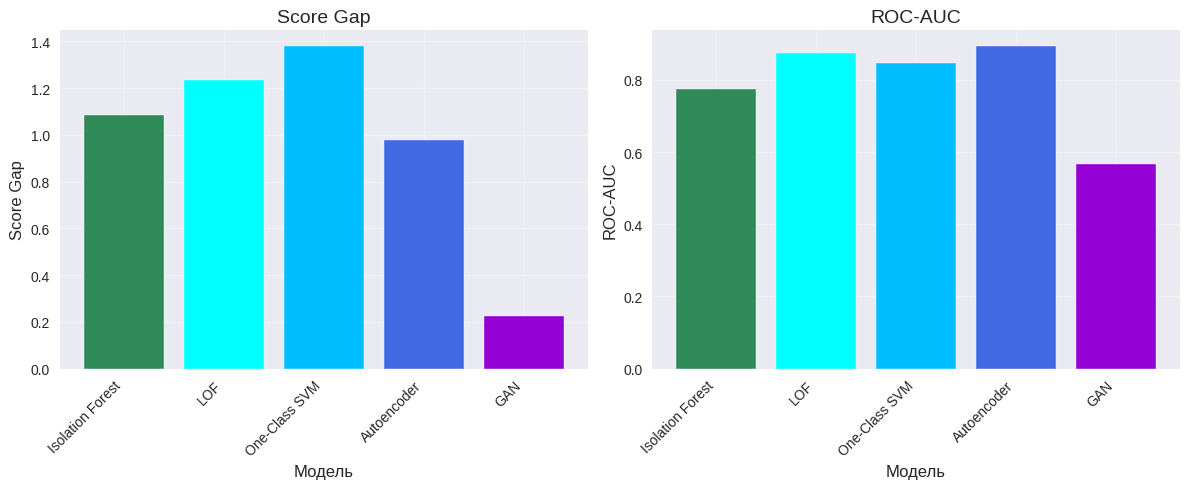

Лучшая модель: Autoencoder
   Score Gap: 0.979
   ROC-AUC: 0.892


In [322]:
# Создание DataFrame с результатами
results = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF', 'One-Class SVM', 'Autoencoder', 'GAN'],
    'Score Gap': [iso_score_gap, lof_score_gap, svm_score_gap, ae_score_gap, gan_score_gap],
    'ROC-AUC': [iso_roc_auc, lof_roc_auc, svm_roc_auc, ae_roc_auc, gan_roc_auc]
})

print(results.sort_values('ROC-AUC', ascending=False))

# Визуализация результатов
plt.figure(figsize=(12, 5))

# График Score Gap
plt.subplot(1, 2, 1)
plt.bar(results['Model'], results['Score Gap'], color=['seagreen', 'aqua', 'deepskyblue', 'royalblue', 'darkviolet'])
plt.title('Score Gap', fontsize=14)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Score Gap', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# График ROC-AUC
plt.subplot(1, 2, 2)
plt.bar(results['Model'], results['ROC-AUC'], color=['seagreen', 'aqua', 'deepskyblue', 'royalblue', 'darkviolet'])
plt.title('ROC-AUC', fontsize=14)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод лучшей модели
best_model = results.loc[results['ROC-AUC'].idxmax()]
print(f"Лучшая модель: {best_model['Model']}")
print(f"   Score Gap: {best_model['Score Gap']:.3f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.3f}")

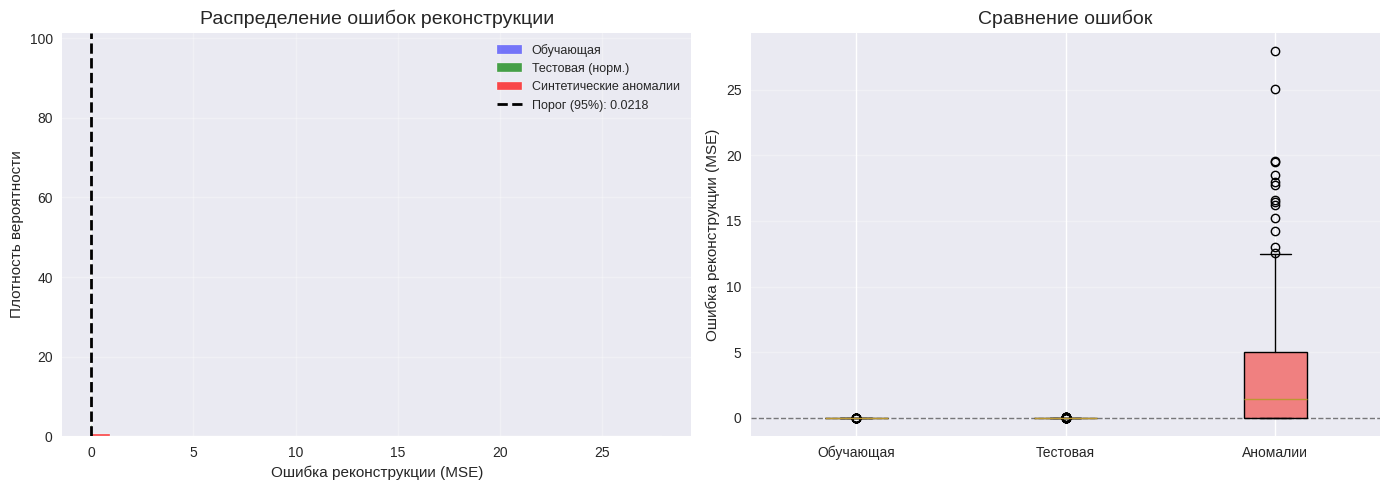


Статистика ошибок реконструкции:
Данные               Среднее      Медиана      Макс        
Обучающая            0.011609     0.010447     0.046013    
Тестовая             0.013495     0.011588     0.068218    
Аномалии             3.080675     1.472430     27.936786   

Порог детекции: 0.021815
Аномалий выше порога: 78.0%
Тестовых выше порога: 11.1%


In [323]:
# Анализ ошибок реконструкции автоэнкодера

# Ошибки на обучающей выборке
train_reconstructions = autoencoder.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - train_reconstructions), axis=1)

# Ошибки на тестовой выборке
test_reconstructions = autoencoder.predict(X_test, verbose=0)
test_errors = np.mean(np.square(X_test - test_reconstructions), axis=1)

# Создаем синтетические аномалии для сравнения
n_anomalies = min(500, len(X_test))
anomalies = generate_anomalies(X_test[:n_anomalies], n_anomalies)
anomaly_reconstructions = autoencoder.predict(anomalies, verbose=0)
anomaly_errors = np.mean(np.square(anomalies - anomaly_reconstructions), axis=1)

# Визуализация
plt.figure(figsize=(14, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(train_errors, bins=50, alpha=0.5, label='Обучающая', color='blue', density=True)
plt.hist(test_errors, bins=30, alpha=0.7, label='Тестовая (норм.)', color='green', density=True)
plt.hist(anomaly_errors, bins=30, alpha=0.7, label='Синтетические аномалии', color='red', density=True)

# Порог
threshold = np.percentile(train_errors, 95)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Порог (95%): {threshold:.4f}')

plt.xlabel('Ошибка реконструкции (MSE)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение ошибок реконструкции', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
box_data = [train_errors[:1000], test_errors[:1000], anomaly_errors[:1000]]
box_labels = ['Обучающая', 'Тестовая', 'Аномалии']
box = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.axhline(threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.ylabel('Ошибка реконструкции (MSE)')
plt.title('Сравнение ошибок', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика ошибок реконструкции:")
print(f"{'Данные':<20} {'Среднее':<12} {'Медиана':<12} {'Макс':<12}")
print(f"{'Обучающая':<20} {train_errors.mean():<12.6f} {np.median(train_errors):<12.6f} {train_errors.max():<12.6f}")
print(f"{'Тестовая':<20} {test_errors.mean():<12.6f} {np.median(test_errors):<12.6f} {test_errors.max():<12.6f}")
print(f"{'Аномалии':<20} {anomaly_errors.mean():<12.6f} {np.median(anomaly_errors):<12.6f} {anomaly_errors.max():<12.6f}")

print(f"\nПорог детекции: {threshold:.6f}")
print(f"Аномалий выше порога: {(anomaly_errors > threshold).sum()/len(anomaly_errors)*100:.1f}%")
print(f"Тестовых выше порога: {(test_errors > threshold).sum()/len(test_errors)*100:.1f}%")

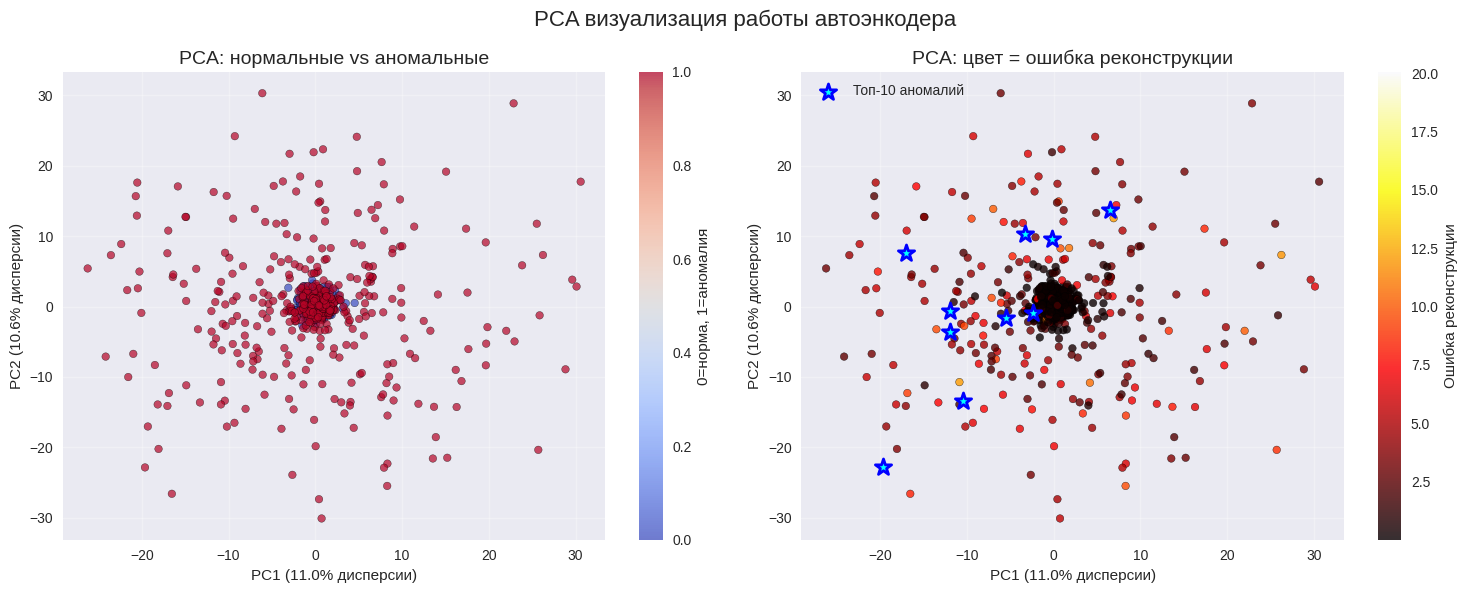


PCA объясняет 21.6% дисперсии
Средняя ошибка нормальных: 0.013495
Средняя ошибка аномалий: 2.715170
Разница: 2.701675


In [324]:
# PCA визуализация для автоэнкодера

# Берем подвыборку для скорости
sample_size = min(1000, len(X_test))
X_sample = X_test[:sample_size]

# Добавляем синтетические аномалии
anomalies_sample = generate_anomalies(X_sample, sample_size)

# Объединяем
X_combined = np.vstack([X_sample, anomalies_sample])
y_combined = np.concatenate([np.zeros(sample_size), np.ones(sample_size)])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

# Ошибки реконструкции
combined_reconstructions = autoencoder.predict(X_combined, verbose=0)
combined_errors = np.mean(np.square(X_combined - combined_reconstructions), axis=1)

# Визуализация
plt.figure(figsize=(15, 6))

# По классам
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_combined, cmap='coolwarm',
                      alpha=0.7, s=30, edgecolor='k', linewidth=0.3)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
plt.title('PCA: нормальные vs аномальные', fontsize=14)
plt.colorbar(scatter1, label='0=норма, 1=аномалия')
plt.grid(True, alpha=0.3)

# По ошибкам
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=combined_errors, cmap='hot',
                      alpha=0.8, s=30, edgecolor='k', linewidth=0.3)

# Выделяем топ-10 аномалий
top_n = 10
top_indices = np.argsort(combined_errors)[-top_n:]
plt.scatter(X_pca[top_indices, 0], X_pca[top_indices, 1],
           s=150, marker='*', c='cyan', edgecolor='blue', linewidth=2,
           label=f'Топ-{top_n} аномалий')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
plt.title('PCA: цвет = ошибка реконструкции', fontsize=14)
plt.colorbar(scatter2, label='Ошибка реконструкции')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('PCA визуализация работы автоэнкодера', fontsize=16)
plt.tight_layout()
plt.show()

# Статистика
print(f"\nPCA объясняет {sum(pca.explained_variance_ratio_[:2])*100:.1f}% дисперсии")
print(f"Средняя ошибка нормальных: {combined_errors[y_combined == 0].mean():.6f}")
print(f"Средняя ошибка аномалий: {combined_errors[y_combined == 1].mean():.6f}")
print(f"Разница: {combined_errors[y_combined == 1].mean() - combined_errors[y_combined == 0].mean():.6f}")